In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/test.csv')
holidays_events = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/holidays_events.csv')
oil = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/oil.csv')
stores = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/stores.csv')
sample_submission = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/sample_submission.csv')
transactions = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/transactions.csv')

In [ ]:
df = {
    'train':train,
    'test':test,
    'holidays_events':holidays_events,
    'oil':oil,
    'stores':stores,
    'sample_submission':sample_submission,
    'transactions': transactions
}

In [ ]:
for i in df:
  print(i,'-->','\n' , df[i].isnull().sum() )

train --> 
 id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
test --> 
 id             0
date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64
holidays_events --> 
 date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64
oil --> 
 date           0
dcoilwtico    43
dtype: int64
stores --> 
 store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64
sample_submission --> 
 id       0
sales    0
dtype: int64
transactions --> 
 date            0
store_nbr       0
transactions    0
dtype: int64


In [ ]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])
holidays_events['date'] = pd.to_datetime(holidays_events['date'])
oil['date'] = pd.to_datetime(oil['date'])
transactions['date'] = pd.to_datetime(transactions['date'])
for name, d in zip(['train','test','oil','holidays_events','transactions'], [train, test, oil, holidays_events, transactions]):
    print(name, d['date'].dtype)

train datetime64[ns]
test datetime64[ns]
oil datetime64[ns]
holidays_events datetime64[ns]
transactions datetime64[ns]


In [ ]:
#for getting idea about when the store started!!
store_start_date = train.groupby('store_nbr')['date'].min()
print(store_start_date.sort_values(ascending = False).head(10))

store_nbr
1    2013-01-01
41   2013-01-01
30   2013-01-01
31   2013-01-01
32   2013-01-01
33   2013-01-01
34   2013-01-01
35   2013-01-01
36   2013-01-01
37   2013-01-01
Name: date, dtype: datetime64[ns]


In [ ]:
#for getting idea when stores started their first sell!!
store_family_start = train[train['sales'] > 0].groupby(['store_nbr', 'family'])['date'].min()
print(store_family_start.sort_values(ascending = False).head(10))

store_nbr  family                 
6          BABY CARE                 2017-07-10
22         LADIESWEAR                2017-04-20
52         AUTOMOTIVE                2017-04-20
           SEAFOOD                   2017-04-20
           BEAUTY                    2017-04-20
           PRODUCE                   2017-04-20
           PREPARED FOODS            2017-04-20
           POULTRY                   2017-04-20
           PLAYERS AND ELECTRONICS   2017-04-20
           PET SUPPLIES              2017-04-20
Name: date, dtype: datetime64[ns]


<Axes: title={'center': 'Total Daily sales (all product and families)'}, xlabel='date'>

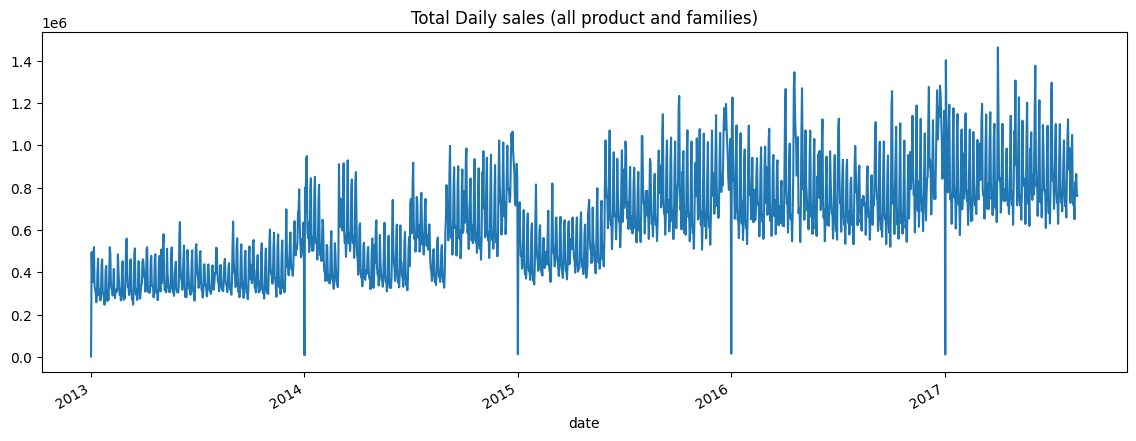

In [ ]:
daily_sales = train.groupby('date')['sales'].sum()
daily_sales.plot(figsize = (14,5), title = "Total Daily sales (all product and families)")

/tmp/ipykernel_279/2969518570.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Monthly_sales = train.set_index('date')['sales'].resample('M').sum()


<Axes: title={'center': 'total monthly sales(all product and families)'}, xlabel='date'>

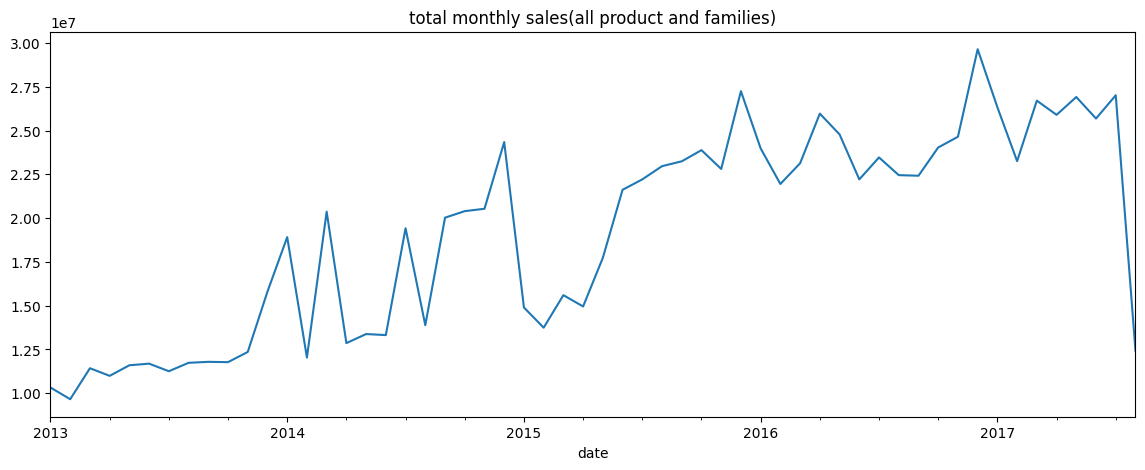

In [ ]:
Monthly_sales = train.set_index('date')['sales'].resample('ME').sum()
Monthly_sales.plot(figsize = (14,5), title = "total monthly sales(all product and families)")

<Axes: title={'center': 'Average Sales by Days'}, xlabel='day_of_week'>

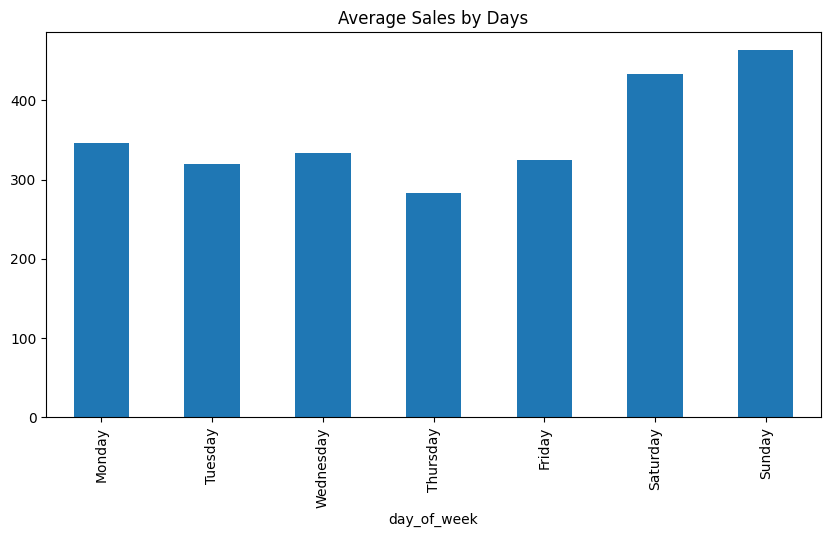

In [ ]:
train['day_of_week'] = train['date'].dt.day_name()
avg_sales_by_day = train.groupby('day_of_week')['sales'].mean().reindex(['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday','Saturday', 'Sunday'])
# print(avg_sales_by_day)
avg_sales_by_day.plot( kind = 'bar', figsize = (10,5), title = 'Average Sales by Days')

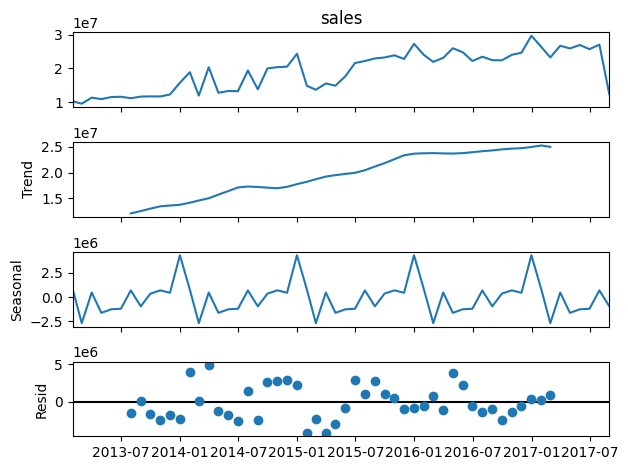

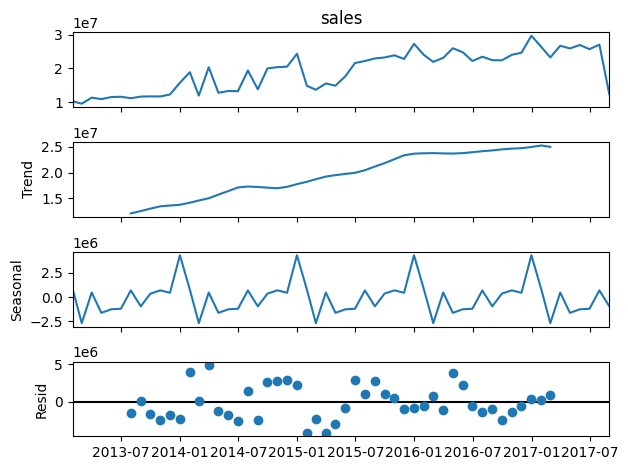

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(Monthly_sales, model ='additive', period = 12)
decomposition.plot()

In [ ]:
from statsmodels.tsa.stattools import adfuller
results = adfuller(Monthly_sales)
print('ADF_statistics', results[0])
print('P-value', results[1])

ADF_statistics -2.0452868889089983
P-value 0.26707594130938095


In [ ]:
train.to_pickle('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/train_cleaned.pkl')